### 04.1 - Modelos Lineares Supervisionados

**Objetivo**  
Aprender os modelos lineares supervisionados mais usados no **scikit-learn**, com código simples e explicações detalhadas:
- **LinearRegression**
- **LogisticRegression**
- **Ridge** e **RidgeClassifier**
- **Lasso**
- **ElasticNet**
- **SGDRegressor** e **SGDClassifier**

In [1]:
import time
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import sklearn

np.random.seed(42)

In [2]:
# geradores de dados e os estimadores lineares
from sklearn.datasets import make_classification, make_regression
from sklearn.dummy import DummyClassifier
from sklearn.inspection import DecisionBoundaryDisplay
from sklearn.linear_model import (
    ElasticNet,
    Lasso,
    LinearRegression,
    LogisticRegression,
    Ridge,
    RidgeClassifier,
    SGDClassifier,
    SGDRegressor,
)

In [3]:
# métricas e displays
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    PrecisionRecallDisplay,
    PredictionErrorDisplay,
    RocCurveDisplay,
    accuracy_score,
    f1_score,
    make_scorer,
    mean_absolute_error,
    precision_score,
    r2_score,
    recall_score,
    roc_auc_score,
    root_mean_squared_error,
)
from sklearn.model_selection import (
    KFold,
    LearningCurveDisplay,
    StratifiedKFold,
    ValidationCurveDisplay,
    cross_validate,
    train_test_split,
)
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler

In [4]:
sns.set_theme(style='whitegrid', context='notebook')

### 1 - Conceito do zero

Todo modelo linear parte da estrutura:

$$
\hat{y} = Xw + b
$$

- **X**: matriz de entrada
- **w**: coeficientes
- **b**: intercepto

Em regressão, o alvo previsto é contínuo. Em classificação, um score linear é convertido em probabilidade/classe.

**API comum do scikit-learn**

- **fit(X, y)**: aprende os parâmetros
- **predict(X)**: gera a predição final
- **predict_proba(X)**: retorna probabilidade (quando suportado)
- **score(X, y)**: métrica padrão do estimador

In [5]:
X_demo_reg, y_demo_reg = make_regression(n_samples=120, n_features=3, noise=10, random_state=42)
reg_demo = LinearRegression().fit(X_demo_reg, y_demo_reg)
print('Predições (regressão):', np.round(reg_demo.predict(X_demo_reg[:3]), 2))

Predições (regressão): [  89.05 -187.54  -88.67]


**Fechando o conceito da API comum**

Depois da demo de regressão, aqui validamos o mesmo padrão **fit/predict** em classificação para fixar o contrato único do scikit-learn.

In [6]:
X_demo_clf, y_demo_clf = make_classification(
    n_samples=180,
    n_features=4,
    n_informative=4,
    n_redundant=0,
    n_clusters_per_class=1,
    random_state=42,
)
clf_demo = make_pipeline(StandardScaler(), LogisticRegression(max_iter=1000, random_state=42)).fit(X_demo_clf, y_demo_clf)
print('Classes previstas:', clf_demo.predict(X_demo_clf[:10]))
print('Probabilidade classe 1:', np.round(clf_demo.predict_proba(X_demo_clf[:3])[:, 1], 3))

Classes previstas: [0 1 0 0 0 1 1 0 1 1]
Probabilidade classe 1: [0.009 0.904 0.454]


### 2 - Cenários sintéticos

Nesta etapa, criamos os dados de forma explícita com **make_regression** e **make_classification**.

### 2.1 - Cenário de regressão **linear_1d**

Esse cenário é ideal para visualizar a reta aprendida.

In [7]:
X_linear_1d, y_linear_1d = make_regression(
    n_samples=360,
    n_features=1,
    n_informative=1,
    noise=20.0,
    random_state=42,
)
X_linear_1d = pd.DataFrame(X_linear_1d, columns=['x1'])
y_linear_1d = pd.Series(y_linear_1d, name='target')

**Leitura visual antes de modelar**

Sempre vale observar o formato dos dados antes do treino. Isso ajuda a justificar a escolha de um modelo linear simples.


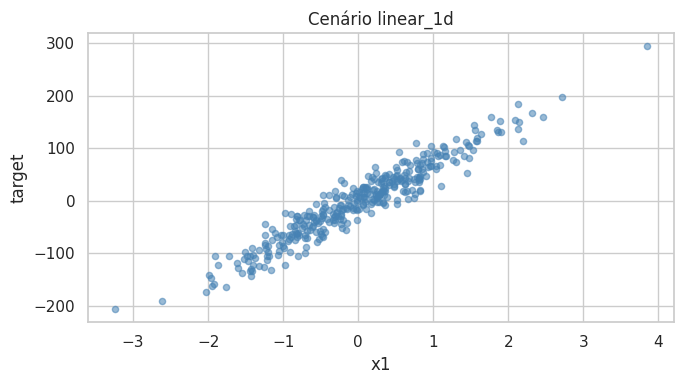

In [8]:
plt.figure(figsize=(7, 4))
plt.scatter(X_linear_1d['x1'], y_linear_1d, alpha=0.55, s=20, color='steelblue')
plt.title('Cenário linear_1d')
plt.xlabel('x1')
plt.ylabel('target')
plt.tight_layout()

### 2.2 - Cenário de regressão **multicolinear**

Usaremos **effective_rank** e **tail_strength** para gerar estrutura de correlação.

In [9]:
X_multi, y_multi, coef_multi_true = make_regression(
    n_samples=1400,
    n_features=12,
    n_informative=8,
    noise=22.0,
    coef=True,
    effective_rank=4,
    tail_strength=0.8,
    random_state=42,
)
X_multi = pd.DataFrame(X_multi, columns=[f'x{i}' for i in range(1, 13)])
y_multi = pd.Series(y_multi, name='target')

**Diagnóstico de multicolinearidade**

O heatmap confirma o cenário em que regularização tende a ajudar: features com dependência entre si.


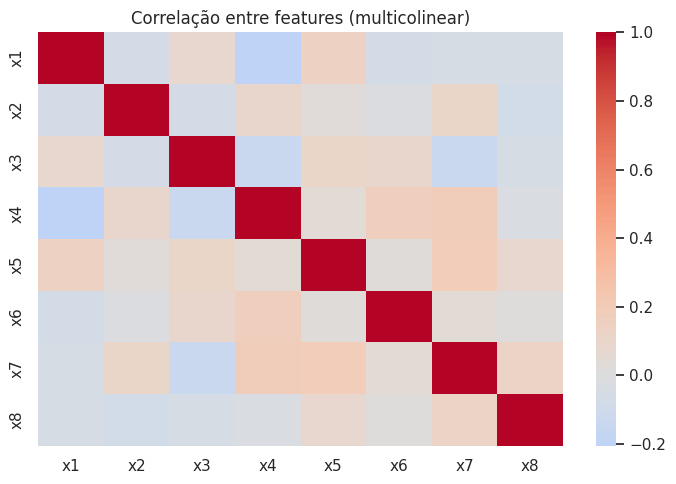

In [10]:
plt.figure(figsize=(7.2, 5))
sns.heatmap(X_multi.iloc[:, :8].corr(), cmap='coolwarm', center=0)
plt.title('Correlação entre features (multicolinear)')
plt.tight_layout()

### 2.3 - Cenário de classificação **linear_2d**

Esse cenário facilita enxergar fronteira de decisão linear.

In [11]:
X_clf_2d, y_clf_2d = make_classification(
    n_samples=800,
    n_features=2,
    n_informative=2,
    n_redundant=0,
    n_clusters_per_class=1,
    class_sep=1.6,
    flip_y=0.02,
    random_state=42,
)
X_clf_2d = pd.DataFrame(X_clf_2d, columns=['x1', 'x2'])
y_clf_2d = pd.Series(y_clf_2d, name='target')

**Geometria do problema de classificação**

Este gráfico antecipa o que esperamos ver na fronteira de decisão dos classificadores lineares.


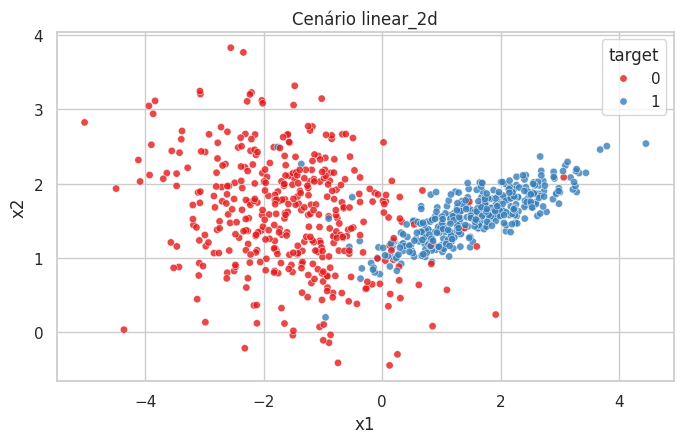

In [12]:
plt.figure(figsize=(7, 4.6))
sns.scatterplot(data=X_clf_2d.assign(target=y_clf_2d), x='x1', y='x2', hue='target', palette='Set1', s=28, alpha=0.8)
plt.title('Cenário linear_2d')
plt.tight_layout()

### 2.4 - Cenários de alto volume

Vamos gerar um cenário grande para regressão e outro para classificação.

In [13]:
X_reg_big, y_reg_big = make_regression(
    n_samples=18000,
    n_features=20,
    n_informative=12,
    noise=30.0,
    random_state=44,
)
X_reg_big = pd.DataFrame(X_reg_big, columns=[f'x{i}' for i in range(1, 21)])
y_reg_big = pd.Series(y_reg_big, name='target')

In [14]:
X_clf_big, y_clf_big = make_classification(
    n_samples=24000,
    n_features=30,
    n_informative=12,
    n_redundant=6,
    n_clusters_per_class=2,
    class_sep=1.2,
    flip_y=0.02,
    weights=[0.55, 0.45],
    random_state=49,
)
X_clf_big = pd.DataFrame(X_clf_big, columns=[f'x{i}' for i in range(1, 31)])
y_clf_big = pd.Series(y_clf_big, name='target')

**Resumo dos cenários**

Esta tabela funciona como mapa do notebook: qual dataset será usado em cada bloco e com qual escala de problema.


In [15]:
scenario_summary = pd.DataFrame([
    ['regressao', 'linear_1d', X_linear_1d.shape[0], X_linear_1d.shape[1]],
    ['regressao', 'multicolinear', X_multi.shape[0], X_multi.shape[1]],
    ['regressao', 'high_volume', X_reg_big.shape[0], X_reg_big.shape[1]],
    ['classificacao', 'linear_2d', X_clf_2d.shape[0], X_clf_2d.shape[1]],
    ['classificacao', 'high_volume_linear', X_clf_big.shape[0], X_clf_big.shape[1]],
], columns=['tipo', 'cenario', 'amostras', 'features'])
scenario_summary

,tipo,cenario,amostras,features
0,regressao,linear_1d,360,1
1,regressao,multicolinear,1400,12
2,regressao,high_volume,18000,20
3,classificacao,linear_2d,800,2
4,classificacao,high_volume_linear,24000,30


### 3 - Método: **LinearRegression**

### O que este método otimiza

$$
\min_w \frac{1}{2n}\|y - Xw\|^2
$$

### Intuição prática
Ele ajusta uma reta que minimiza o erro quadrático médio entre valor real e previsto.

### Como interpretar métricas
- **RMSE**: erro típico na escala do alvo.
- **MAE**: erro absoluto médio.
- **R²**: fração da variância explicada.

### Quando usar / quando evitar
- Usar em relações aproximadamente lineares.
- Evitar quando o padrão real é fortemente não linear.

### Erros comuns específicos do método
- Avaliar só treino.
- Usar apenas **R²** e ignorar **RMSE**/**MAE**.

In [16]:
X_train_lin, X_test_lin, y_train_lin, y_test_lin = train_test_split(
    X_linear_1d,
    y_linear_1d,
    test_size=0.25,
    random_state=42,
)

In [17]:
lin_model = LinearRegression()
lin_model.fit(X_train_lin, y_train_lin)

lin_pred_train = lin_model.predict(X_train_lin)
lin_pred_test = lin_model.predict(X_test_lin)

**Métricas principais da regressão linear**

Aqui medimos erro de treino e teste. A comparação entre eles mostra se o modelo generaliza bem.


In [18]:
lin_metrics = pd.DataFrame([{
    'model': 'LinearRegression',
    'rmse_train': root_mean_squared_error(y_train_lin, lin_pred_train),
    'rmse_test': root_mean_squared_error(y_test_lin, lin_pred_test),
    'mae_test': mean_absolute_error(y_test_lin, lin_pred_test),
    'r2_test': r2_score(y_test_lin, lin_pred_test),
    'coef_x1': lin_model.coef_[0],
    'intercept': lin_model.intercept_,
}])
lin_metrics.round(4)

,model,rmse_train,rmse_test,mae_test,r2_test,coef_x1,intercept
0,LinearRegression,20.839,19.7842,15.429,0.9296,72.6747,-0.4675


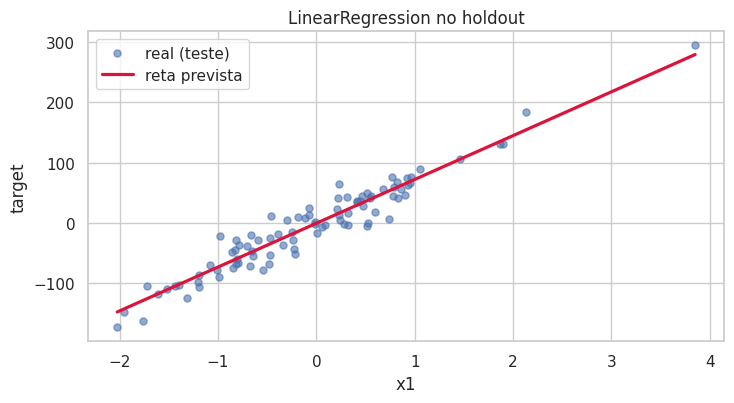

In [19]:
order = np.argsort(X_test_lin['x1'].values)
X_plot = X_test_lin.iloc[order]

plt.figure(figsize=(7.5, 4.2))
plt.scatter(X_test_lin['x1'], y_test_lin, alpha=0.6, s=26, label='real (teste)')
plt.plot(X_plot['x1'], lin_model.predict(X_plot), color='crimson', linewidth=2.3, label='reta prevista')
plt.title('LinearRegression no holdout')
plt.xlabel('x1')
plt.ylabel('target')
plt.legend()
plt.tight_layout()

**Segundo olhar no erro**

Além da reta ajustada, este display mostra alinhamento entre real e previsto de forma padronizada pelo sklearn.


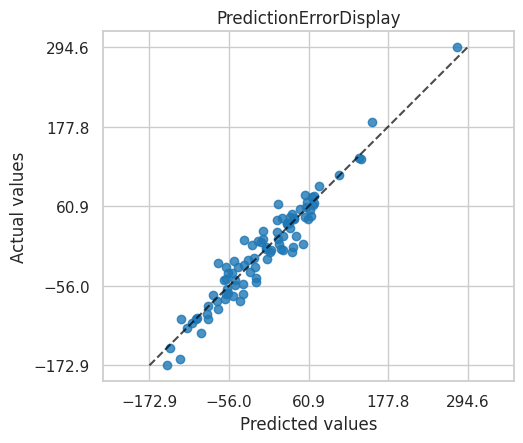

In [20]:
fig, ax = plt.subplots(figsize=(5.4, 4.6))
PredictionErrorDisplay.from_estimator(lin_model, X_test_lin, y_test_lin, kind='actual_vs_predicted', ax=ax)
ax.set_title('PredictionErrorDisplay')
plt.tight_layout()

### 4 - Método: **LogisticRegression**

### Intuição prática
O modelo aprende uma fronteira linear e retorna probabilidade da classe positiva.

### Como interpretar métricas
- **Accuracy**, **Precision**, **Recall**, **F1**, **ROC-AUC**.
- Em problemas reais, escolha a métrica com base no custo de erro.

### Quando usar / quando evitar
- Usar para classificação binária com padrão linear.
- Evitar quando a separação exige fronteira muito complexa.

### Erros comuns específicos do método
- Não padronizar features.
- Usar só **accuracy** para decidir modelo.

In [21]:
X_train_log, X_test_log, y_train_log, y_test_log = train_test_split(
    X_clf_2d,
    y_clf_2d,
    test_size=0.25,
    random_state=42,
    stratify=y_clf_2d,
)

In [22]:
dummy_log = DummyClassifier(strategy='most_frequent')
log_model = make_pipeline(StandardScaler(), LogisticRegression(max_iter=1000, random_state=42))

dummy_log.fit(X_train_log, y_train_log)
log_model.fit(X_train_log, y_train_log)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('standardscaler', ...), ('logisticregression', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"copy copy: bool, default=TrueIf False, try to avoid a copy and do inplace scaling instead.This is not guaranteed to always work inplace; e.g. if the data isnot a NumPy array or scipy.sparse CSR matrix, a copy may still bereturned.",True
,"with_mean with_mean: bool, default=TrueIf True, center the data before scaling.This does not work (and will raise an exception) when attempted onsparse matrices, because centering them entails building a densematrix which in common use cases is likely to be too large to fit inmemory.",True
,"with_std with_std: bool, default=TrueIf True, scale the data to unit variance (or equivalently,unit standard deviation).",True
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some 

In [23]:
dummy_pred = dummy_log.predict(X_test_log)
log_pred = log_model.predict(X_test_log)

dummy_score = dummy_log.predict_proba(X_test_log)[:, 1]
log_score = log_model.predict_proba(X_test_log)[:, 1]

**Comparação objetiva: baseline vs logística**

Esta tabela responde à pergunta central da seção: o modelo realmente aprende algo além do chute mais frequente?


In [24]:
log_metrics = pd.DataFrame([
    {
        'model': 'DummyClassifier',
        'accuracy_test': accuracy_score(y_test_log, dummy_pred),
        'precision_test': precision_score(y_test_log, dummy_pred, zero_division=0),
        'recall_test': recall_score(y_test_log, dummy_pred, zero_division=0),
        'f1_test': f1_score(y_test_log, dummy_pred, zero_division=0),
        'roc_auc_test': roc_auc_score(y_test_log, dummy_score),
    },
    {
        'model': 'LogisticRegression',
        'accuracy_test': accuracy_score(y_test_log, log_pred),
        'precision_test': precision_score(y_test_log, log_pred, zero_division=0),
        'recall_test': recall_score(y_test_log, log_pred, zero_division=0),
        'f1_test': f1_score(y_test_log, log_pred, zero_division=0),
        'roc_auc_test': roc_auc_score(y_test_log, log_score),
    },
]).sort_values('f1_test', ascending=False).reset_index(drop=True)

log_metrics.round(4)

,model,accuracy_test,precision_test,recall_test,f1_test,roc_auc_test
0,LogisticRegression,0.945,0.9314,0.9596,0.9453,0.9807
1,DummyClassifier,0.505,0.0000,0.0000,0.0000,0.5000


**Onde o classificador erra?**

A matriz de confusão detalha os tipos de erro e complementa o F1/ROC-AUC com interpretação operacional.


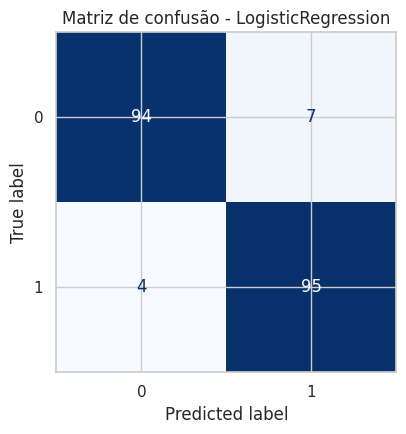

In [25]:
fig, ax = plt.subplots(figsize=(5, 4.5))
ConfusionMatrixDisplay.from_estimator(log_model, X_test_log, y_test_log, cmap='Blues', colorbar=False, ax=ax)
ax.set_title('Matriz de confusão - LogisticRegression')
plt.tight_layout()

**Fronteira de decisão**

Aqui vemos como o modelo separa classes no plano e onde a incerteza tende a aumentar.


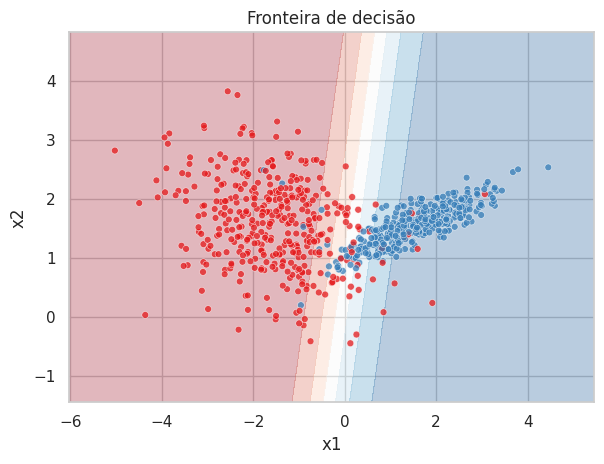

In [26]:
fig, ax = plt.subplots(figsize=(6.2, 4.8))
DecisionBoundaryDisplay.from_estimator(log_model, X_clf_2d, response_method='predict_proba', alpha=0.3, cmap='RdBu', ax=ax)
sns.scatterplot(data=X_clf_2d.assign(target=y_clf_2d), x='x1', y='x2', hue='target', palette='Set1', s=24, alpha=0.75, ax=ax, legend=False)
ax.set_title('Fronteira de decisão')
plt.tight_layout()

**Curvas para decisão de limiar**

ROC e Precision-Recall mostram comportamento para vários limiares, não apenas o corte fixo de 0.5.


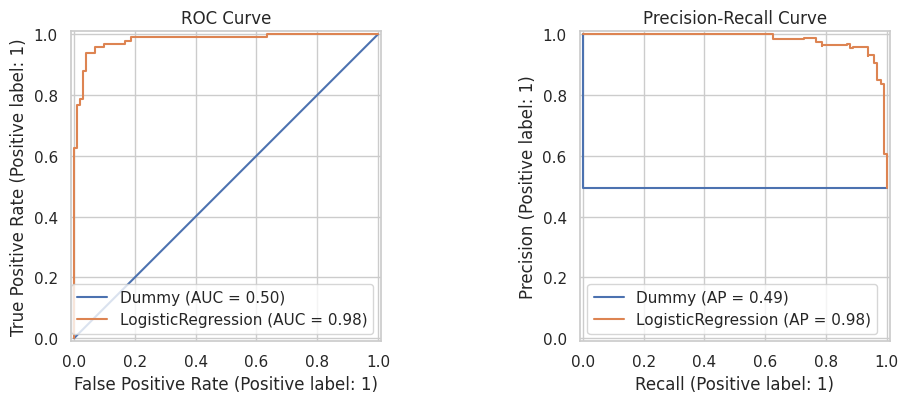

In [27]:
fig, axes = plt.subplots(1, 2, figsize=(10.5, 4.2))
RocCurveDisplay.from_estimator(dummy_log, X_test_log, y_test_log, ax=axes[0], name='Dummy')
RocCurveDisplay.from_estimator(log_model, X_test_log, y_test_log, ax=axes[0], name='LogisticRegression')
axes[0].set_title('ROC Curve')

PrecisionRecallDisplay.from_estimator(dummy_log, X_test_log, y_test_log, ax=axes[1], name='Dummy')
PrecisionRecallDisplay.from_estimator(log_model, X_test_log, y_test_log, ax=axes[1], name='LogisticRegression')
axes[1].set_title('Precision-Recall Curve')
plt.tight_layout()

### 5 - Método: **Ridge** e **RidgeClassifier**

No **RidgeClassifier**, a ideia é similar: score linear com regularização L2 e decisão por sinal/score.

**Intuição prática**
A regularização L2 reduz coeficientes extremos e melhora estabilidade em dados correlacionados.

**Como interpretar métricas**
Observe como **RMSE** e a norma dos coeficientes mudam com **alpha**.

**Quando usar / quando evitar**
- Usar quando há multicolinearidade.
- Evitar se o objetivo principal for zerar variáveis (Lasso costuma ser mais adequado).

**Erros comuns específicos do método**
- Escolher **alpha** sem validação.
- Não padronizar antes da penalização.

In [28]:
X_train_mul, X_test_mul, y_train_mul, y_test_mul = train_test_split(
    X_multi,
    y_multi,
    test_size=0.25,
    random_state=42,
)

In [29]:
ridge_alphas = [0.01, 0.1, 1, 10, 100, 300]
ridge_rows = []

ols_ref = make_pipeline(StandardScaler(), LinearRegression()).fit(X_train_mul, y_train_mul)
ols_rmse = root_mean_squared_error(y_test_mul, ols_ref.predict(X_test_mul))
ols_norm = np.linalg.norm(ols_ref.named_steps['linearregression'].coef_, ord=2)

**Varredura de regularização L2**

Vamos testar vários **alpha** para observar o trade-off entre estabilidade dos coeficientes e erro no teste.


In [30]:
for alpha in ridge_alphas:
    ridge_model = make_pipeline(StandardScaler(), Ridge(alpha=alpha, random_state=42))
    ridge_model.fit(X_train_mul, y_train_mul)
    ridge_rows.append({
        'alpha': alpha,
        'rmse_test': root_mean_squared_error(y_test_mul, ridge_model.predict(X_test_mul)),
        'coef_l2_norm': np.linalg.norm(ridge_model.named_steps['ridge'].coef_, ord=2),
    })

ridge_scan = pd.DataFrame(ridge_rows)
ridge_scan

,alpha,rmse_test,coef_l2_norm
0,0.01,21.211469,4.380575
1,0.10,21.211445,4.380218
2,1.00,21.211208,4.376652
3,10.00,21.208918,4.341375
4,100.00,21.192237,4.022445
5,300.00,21.180794,3.475120


**Como escolher alpha no Ridge**

Use o primeiro gráfico para erro e o segundo para magnitude dos coeficientes. O melhor ponto costuma equilibrar os dois.


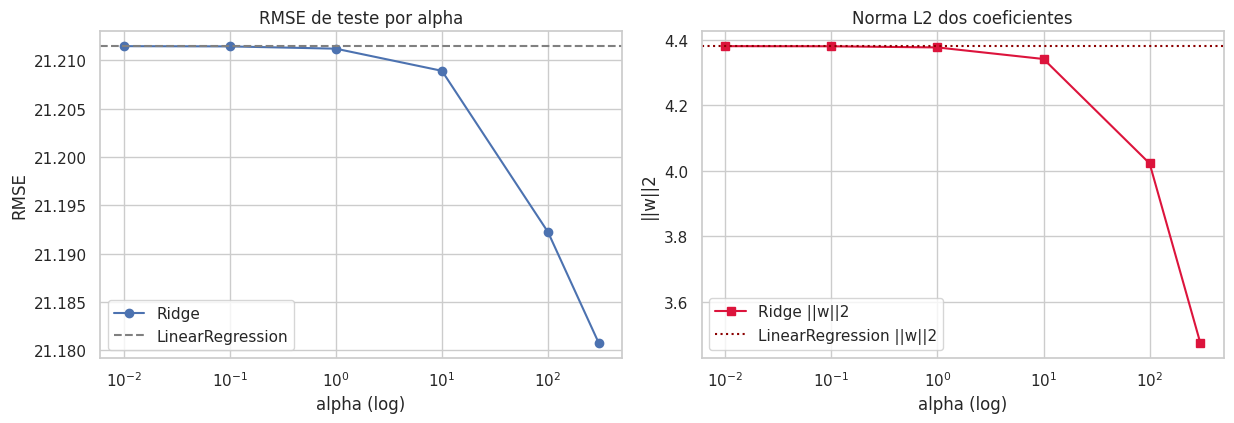

In [31]:
fig, axes = plt.subplots(1, 2, figsize=(12.5, 4.4))

axes[0].semilogx(ridge_scan['alpha'], ridge_scan['rmse_test'], marker='o', label='Ridge')
axes[0].axhline(ols_rmse, linestyle='--', color='gray', label='LinearRegression')
axes[0].set_title('RMSE de teste por alpha')
axes[0].set_xlabel('alpha (log)')
axes[0].set_ylabel('RMSE')
axes[0].legend()

axes[1].semilogx(ridge_scan['alpha'], ridge_scan['coef_l2_norm'], marker='s', color='crimson', label='Ridge ||w||2')
axes[1].axhline(ols_norm, linestyle=':', color='darkred', label='LinearRegression ||w||2')
axes[1].set_title('Norma L2 dos coeficientes')
axes[1].set_xlabel('alpha (log)')
axes[1].set_ylabel('||w||2')
axes[1].legend()

plt.tight_layout()

In [32]:
ridge_clf = make_pipeline(StandardScaler(), RidgeClassifier(alpha=1.0, random_state=42))
log_clf_ref = make_pipeline(StandardScaler(), LogisticRegression(max_iter=1000, random_state=42))
dummy_clf_ref = DummyClassifier(strategy='most_frequent')

In [33]:
dummy_clf_ref.fit(X_train_log, y_train_log)
log_clf_ref.fit(X_train_log, y_train_log)
ridge_clf.fit(X_train_log, y_train_log)

dummy_pred_rc = dummy_clf_ref.predict(X_test_log)
log_pred_rc = log_clf_ref.predict(X_test_log)
ridge_pred_rc = ridge_clf.predict(X_test_log)

**RidgeClassifier em comparação direta**

Nesta tabela, avaliamos se a versão classificatória do Ridge compete bem com logística no mesmo cenário.


In [34]:
ridge_cls_metrics = pd.DataFrame([
    {
        'model': 'DummyClassifier',
        'accuracy_test': accuracy_score(y_test_log, dummy_pred_rc),
        'precision_test': precision_score(y_test_log, dummy_pred_rc, zero_division=0),
        'recall_test': recall_score(y_test_log, dummy_pred_rc, zero_division=0),
        'f1_test': f1_score(y_test_log, dummy_pred_rc, zero_division=0),
        'roc_auc_test': roc_auc_score(y_test_log, dummy_clf_ref.predict_proba(X_test_log)[:, 1]),
    },
    {
        'model': 'LogisticRegression',
        'accuracy_test': accuracy_score(y_test_log, log_pred_rc),
        'precision_test': precision_score(y_test_log, log_pred_rc, zero_division=0),
        'recall_test': recall_score(y_test_log, log_pred_rc, zero_division=0),
        'f1_test': f1_score(y_test_log, log_pred_rc, zero_division=0),
        'roc_auc_test': roc_auc_score(y_test_log, log_clf_ref.predict_proba(X_test_log)[:, 1]),
    },
    {
        'model': 'RidgeClassifier',
        'accuracy_test': accuracy_score(y_test_log, ridge_pred_rc),
        'precision_test': precision_score(y_test_log, ridge_pred_rc, zero_division=0),
        'recall_test': recall_score(y_test_log, ridge_pred_rc, zero_division=0),
        'f1_test': f1_score(y_test_log, ridge_pred_rc, zero_division=0),
        'roc_auc_test': roc_auc_score(y_test_log, ridge_clf.decision_function(X_test_log)),
    },
]).sort_values('f1_test', ascending=False).reset_index(drop=True)

ridge_cls_metrics.round(4)

,model,accuracy_test,precision_test,recall_test,f1_test,roc_auc_test
0,LogisticRegression,0.945,0.9314,0.9596,0.9453,0.9807
1,RidgeClassifier,0.930,0.9048,0.9596,0.9314,0.9810
2,DummyClassifier,0.505,0.0000,0.0000,0.0000,0.5000


### 7 - Método: **Lasso** e **ElasticNet**

**Intuição prática**
- Lasso tende a zerar coeficientes.
- ElasticNet equilibra seleção e estabilidade.

**Como interpretar métricas**
Compare erro de teste e observe quantos coeficientes ficam próximos de zero.

**Quando usar / quando evitar**
- Lasso: bom para simplificar o modelo.
- ElasticNet: melhor quando há correlação entre variáveis.

**Erros comuns específicos do método**
- Achar que “mais zeros” sempre significa melhor modelo.
- Não validar **alpha** e **l1_ratio**.

In [35]:
lin_ref = make_pipeline(StandardScaler(), LinearRegression())
ridge_ref = make_pipeline(StandardScaler(), Ridge(alpha=10.0, random_state=42))
lasso_model = make_pipeline(StandardScaler(), Lasso(alpha=0.12, max_iter=8000, random_state=42))
elastic_model = make_pipeline(StandardScaler(), ElasticNet(alpha=0.08, l1_ratio=0.4, max_iter=8000, random_state=42))

In [36]:
reg_models_l1l2 = [
    ('LinearRegression', lin_ref),
    ('Ridge(alpha=10)', ridge_ref),
    ('Lasso(alpha=0.12)', lasso_model),
    ('ElasticNet(alpha=0.08,l1_ratio=0.4)', elastic_model),
]

**Benchmark L1/L2 lado a lado**

Com o mesmo split e mesmas métricas, fica mais fácil entender o efeito prático de cada penalização.


In [37]:
rows_l1l2 = []
for name, model in reg_models_l1l2:
    model.fit(X_train_mul, y_train_mul)
    pred_train = model.predict(X_train_mul)
    pred_test = model.predict(X_test_mul)
    rows_l1l2.append({
        'model': name,
        'rmse_train': root_mean_squared_error(y_train_mul, pred_train),
        'rmse_test': root_mean_squared_error(y_test_mul, pred_test),
        'mae_test': mean_absolute_error(y_test_mul, pred_test),
        'r2_test': r2_score(y_test_mul, pred_test),
    })

l1l2_metrics = pd.DataFrame(rows_l1l2).sort_values('rmse_test').reset_index(drop=True)
l1l2_metrics.round(4)

,model,rmse_train,rmse_test,mae_test,r2_test
0,"ElasticNet(alpha=0.08,l1_ratio=0.4)",22.2419,21.2056,16.9258,0.0301
1,Ridge(alpha=10),22.2402,21.2089,16.9137,0.0298
2,LinearRegression,22.2402,21.2115,16.9132,0.0295
3,Lasso(alpha=0.12),22.2433,21.2250,16.9456,0.0283


**Esparsidade explicada por números**

A contagem de coeficientes próximos de zero mostra de forma objetiva o efeito de seleção do Lasso.


In [38]:
lasso_coef = lasso_model.fit(X_train_mul, y_train_mul).named_steps['lasso'].coef_
elastic_coef = elastic_model.fit(X_train_mul, y_train_mul).named_steps['elasticnet'].coef_

print('Coeficientes ~0 no Lasso:', int(np.isclose(lasso_coef, 0, atol=1e-6).sum()))
print('Coeficientes ~0 no ElasticNet:', int(np.isclose(elastic_coef, 0, atol=1e-6).sum()))

Coeficientes ~0 no Lasso: 1
Coeficientes ~0 no ElasticNet: 0


**Esparsidade explicada por visual**

Agora traduzimos os coeficientes em gráficos para identificar quais variáveis permanecem relevantes.


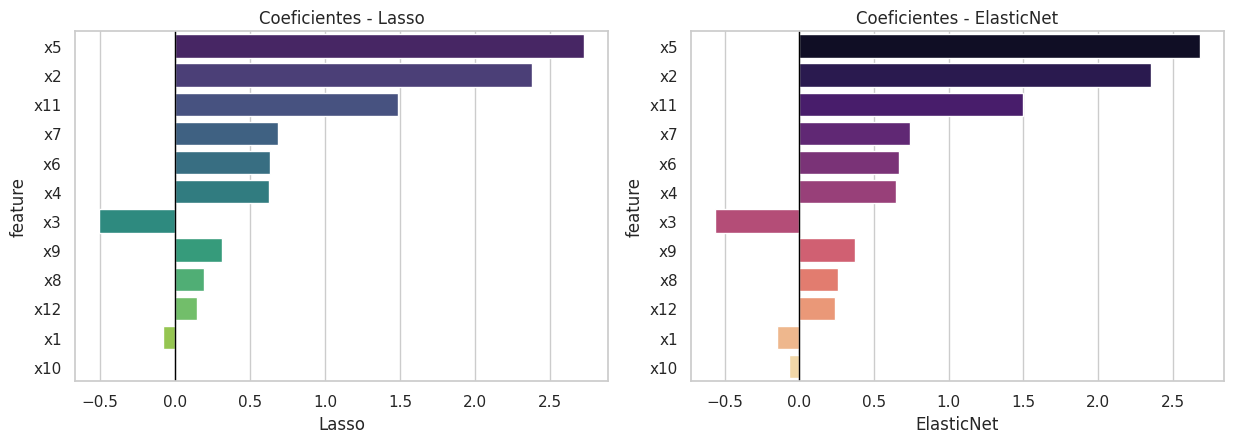

In [39]:
coef_df = pd.DataFrame({'feature': X_multi.columns, 'Lasso': lasso_coef, 'ElasticNet': elastic_coef})

fig, axes = plt.subplots(1, 2, figsize=(12.5, 4.6))

plot_lasso = coef_df.sort_values('Lasso', key=np.abs, ascending=False)
sns.barplot(data=plot_lasso, x='Lasso', y='feature', hue='feature', palette='viridis', legend=False, ax=axes[0])
axes[0].axvline(0, color='black', linewidth=1)
axes[0].set_title('Coeficientes - Lasso')

plot_elastic = coef_df.sort_values('ElasticNet', key=np.abs, ascending=False)
sns.barplot(data=plot_elastic, x='ElasticNet', y='feature', hue='feature', palette='magma', legend=False, ax=axes[1])
axes[1].axvline(0, color='black', linewidth=1)
axes[1].set_title('Coeficientes - ElasticNet')

plt.tight_layout()

### 8 - Método: **SGDRegressor** e **SGDClassifier**

**Intuição prática**
O SGD atualiza parâmetros em passos pequenos e escala melhor em grandes volumes.

**Como interpretar métricas**
Compare desempenho com modelo de referência e também tempo de treino.

**Quando usar / quando evitar**
- Usar em dados grandes.
- Evitar quando não há padronização e ajuste mínimo de hiperparâmetros.

**Erros comuns específicos do método**
- Ignorar escala das variáveis.
- Não monitorar curva de validação/aprendizado.

In [40]:
X_train_big_reg, X_test_big_reg, y_train_big_reg, y_test_big_reg = train_test_split(
    X_reg_big,
    y_reg_big,
    test_size=0.25,
    random_state=42,
)

In [41]:
ridge_big = make_pipeline(StandardScaler(), Ridge(alpha=1.0, random_state=42))
sgd_reg = make_pipeline(StandardScaler(), SGDRegressor(loss='squared_error', alpha=0.0001, max_iter=2500, tol=1e-3, random_state=42))

**SGD em regressão: qualidade vs custo**

Vamos medir erro e tempo de treino para ver quando a otimização estocástica compensa em datasets maiores.


In [42]:
rows_sgd_reg = []
for name, model in [('Ridge_ref', ridge_big), ('SGDRegressor', sgd_reg)]:
    start = time.perf_counter()
    model.fit(X_train_big_reg, y_train_big_reg)
    fit_time = time.perf_counter() - start
    pred_test = model.predict(X_test_big_reg)
    rows_sgd_reg.append({
        'model': name,
        'rmse_test': root_mean_squared_error(y_test_big_reg, pred_test),
        'mae_test': mean_absolute_error(y_test_big_reg, pred_test),
        'r2_test': r2_score(y_test_big_reg, pred_test),
        'fit_time_s': fit_time,
    })

pd.DataFrame(rows_sgd_reg).sort_values('rmse_test').reset_index(drop=True).round(4)

,model,rmse_test,mae_test,r2_test,fit_time_s
0,Ridge_ref,30.5847,24.4906,0.9814,0.0125
1,SGDRegressor,30.6690,24.5641,0.9813,0.0376


In [43]:
sample_reg_idx = X_train_big_reg.sample(n=5000, random_state=42).index
X_reg_sample = X_train_big_reg.loc[sample_reg_idx]
y_reg_sample = y_train_big_reg.loc[sample_reg_idx]

**Sensibilidade de hiperparâmetro no SGDRegressor**

A curva de validação ajuda a evitar escolhas extremas de **alpha** que degradam generalização.


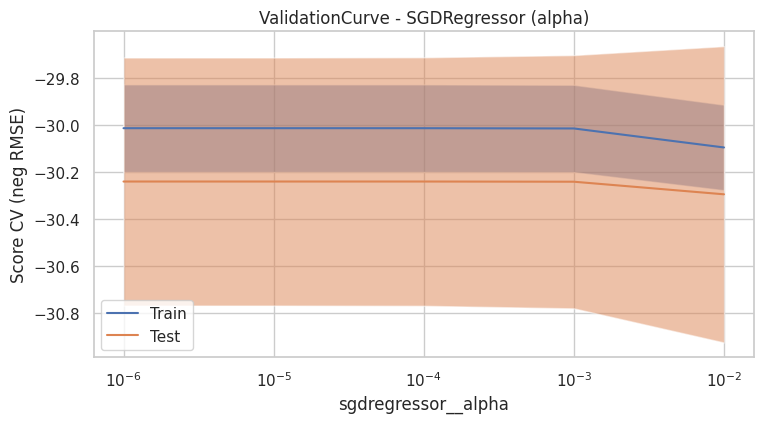

In [44]:
fig, ax = plt.subplots(figsize=(7.8, 4.4))
ValidationCurveDisplay.from_estimator(
    make_pipeline(StandardScaler(), SGDRegressor(loss='squared_error', max_iter=2500, tol=1e-3, random_state=42)),
    X_reg_sample,
    y_reg_sample,
    param_name='sgdregressor__alpha',
    param_range=np.logspace(-6, -2, 5),
    scoring='neg_root_mean_squared_error',
    cv=4,
    ax=ax,
)
ax.set_title('ValidationCurve - SGDRegressor (alpha)')
ax.set_ylabel('Score CV (neg RMSE)')
plt.tight_layout()

In [45]:
X_train_big_clf, X_test_big_clf, y_train_big_clf, y_test_big_clf = train_test_split(
    X_clf_big,
    y_clf_big,
    test_size=0.25,
    random_state=42,
    stratify=y_clf_big,
)

In [46]:
dummy_big = DummyClassifier(strategy='most_frequent')
log_big = make_pipeline(StandardScaler(), LogisticRegression(max_iter=1500, random_state=42))
sgd_big = make_pipeline(StandardScaler(), SGDClassifier(loss='log_loss', alpha=0.0001, max_iter=2500, tol=1e-3, random_state=42))

**SGD em classificação com alto volume**

Aqui comparamos baseline, logística e SGD com foco em F1/ROC-AUC e tempo de ajuste.


In [47]:
rows_sgd_clf = []
for name, model in [('DummyClassifier', dummy_big), ('LogisticRegression', log_big), ('SGDClassifier_log_loss', sgd_big)]:
    start = time.perf_counter()
    model.fit(X_train_big_clf, y_train_big_clf)
    fit_time = time.perf_counter() - start

    pred = model.predict(X_test_big_clf)
    score = model.predict_proba(X_test_big_clf)[:, 1] if hasattr(model, 'predict_proba') else model.decision_function(X_test_big_clf)
    rows_sgd_clf.append({
        'model': name,
        'accuracy_test': accuracy_score(y_test_big_clf, pred),
        'precision_test': precision_score(y_test_big_clf, pred, zero_division=0),
        'recall_test': recall_score(y_test_big_clf, pred, zero_division=0),
        'f1_test': f1_score(y_test_big_clf, pred, zero_division=0),
        'roc_auc_test': roc_auc_score(y_test_big_clf, score),
        'fit_time_s': fit_time,
    })

pd.DataFrame(rows_sgd_clf).sort_values('f1_test', ascending=False).reset_index(drop=True).round(4)

,model,accuracy_test,precision_test,recall_test,f1_test,roc_auc_test,fit_time_s
0,LogisticRegression,0.9115,0.9040,0.8997,0.9019,0.9661,0.0922
1,SGDClassifier_log_loss,0.9098,0.9052,0.8942,0.8996,0.9638,0.1998
2,DummyClassifier,0.5480,0.0000,0.0000,0.0000,0.5000,0.0019


In [48]:
sample_clf_idx = X_train_big_clf.sample(n=8000, random_state=42).index
X_clf_sample = X_train_big_clf.loc[sample_clf_idx]
y_clf_sample = y_train_big_clf.loc[sample_clf_idx]

**Quanto dado é suficiente?**

A curva de aprendizado mostra se aumentar dados ainda traz ganho real de performance.


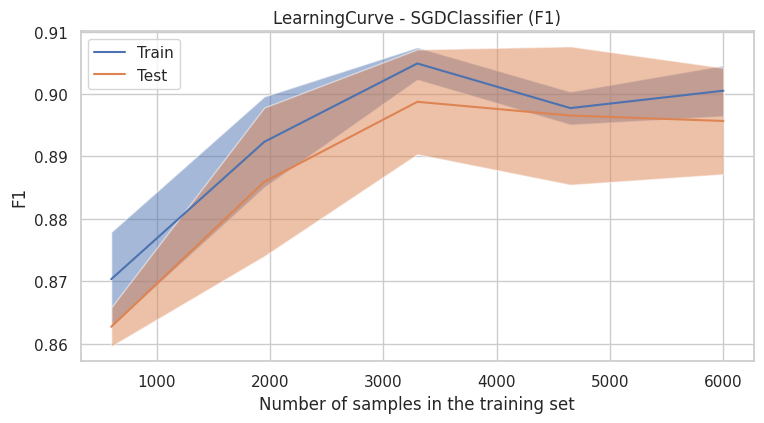

In [49]:
fig, ax = plt.subplots(figsize=(7.8, 4.4))
LearningCurveDisplay.from_estimator(
    make_pipeline(StandardScaler(), SGDClassifier(loss='log_loss', alpha=0.0001, max_iter=2500, tol=1e-3, random_state=42)),
    X_clf_sample,
    y_clf_sample,
    cv=4,
    scoring='f1',
    ax=ax,
)
ax.set_title('LearningCurve - SGDClassifier (F1)')
plt.tight_layout()

### 9 - Comparativo final com **cross_validate**

Agora consolidamos resultados com validação cruzada para reduzir dependência de uma única divisão treino/teste.

In [50]:
cv_reg = KFold(n_splits=5, shuffle=True, random_state=42)

reg_models_cv = {
    'LinearRegression': make_pipeline(StandardScaler(), LinearRegression()),
    'Ridge(alpha=10)': make_pipeline(StandardScaler(), Ridge(alpha=10.0, random_state=42)),
    'Lasso(alpha=0.12)': make_pipeline(StandardScaler(), Lasso(alpha=0.12, max_iter=8000, random_state=42)),
    'ElasticNet(alpha=0.08,l1_ratio=0.4)': make_pipeline(StandardScaler(), ElasticNet(alpha=0.08, l1_ratio=0.4, max_iter=8000, random_state=42)),
    'SGDRegressor': make_pipeline(StandardScaler(), SGDRegressor(loss='squared_error', alpha=0.0001, max_iter=2500, tol=1e-3, random_state=42)),
}

**Comparativo final de regressão com CV**

Agora deixamos o holdout e usamos validação cruzada para reduzir variância da conclusão.


In [51]:
rows_cv_reg = []
for name, model in reg_models_cv.items():
    out = cross_validate(
        model,
        X_multi,
        y_multi,
        cv=cv_reg,
        scoring={'rmse': 'neg_root_mean_squared_error', 'mae': 'neg_mean_absolute_error', 'r2': 'r2'},
        error_score=np.nan,
    )
    rows_cv_reg.append({
        'model': name,
        'rmse_cv_mean': -out['test_rmse'].mean(),
        'mae_cv_mean': -out['test_mae'].mean(),
        'r2_cv_mean': out['test_r2'].mean(),
    })

cv_reg_table = pd.DataFrame(rows_cv_reg).sort_values('rmse_cv_mean').reset_index(drop=True)
cv_reg_table.round(4)

,model,rmse_cv_mean,mae_cv_mean,r2_cv_mean
0,"ElasticNet(alpha=0.08,l1_ratio=0.4)",22.1072,17.6653,0.0274
1,Lasso(alpha=0.12),22.1086,17.6634,0.0273
2,SGDRegressor,22.1130,17.6684,0.0269
3,Ridge(alpha=10),22.1160,17.6714,0.0267
4,LinearRegression,22.1176,17.6725,0.0265


In [52]:
cv_clf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

clf_models_cv = {
    'DummyClassifier': DummyClassifier(strategy='most_frequent'),
    'LogisticRegression': make_pipeline(StandardScaler(), LogisticRegression(max_iter=1500, random_state=42)),
    'RidgeClassifier': make_pipeline(StandardScaler(), RidgeClassifier(alpha=1.0, random_state=42)),
    'SGDClassifier_log_loss': make_pipeline(StandardScaler(), SGDClassifier(loss='log_loss', alpha=0.0001, max_iter=2500, tol=1e-3, random_state=42)),
}

**Comparativo final de classificação com CV**

Esta tabela final consolida os modelos em múltiplos folds, gerando uma decisão mais robusta.


In [53]:
rows_cv_clf = []
for name, model in clf_models_cv.items():
    out = cross_validate(
        model,
        X_clf_big,
        y_clf_big,
        cv=cv_clf,
        scoring={
            'accuracy': 'accuracy',
            'precision': make_scorer(precision_score, zero_division=0),
            'recall': make_scorer(recall_score, zero_division=0),
            'f1': make_scorer(f1_score, zero_division=0),
            'roc_auc': 'roc_auc',
        },
        error_score=np.nan,
    )
    rows_cv_clf.append({
        'model': name,
        'accuracy_cv_mean': out['test_accuracy'].mean(),
        'precision_cv_mean': out['test_precision'].mean(),
        'recall_cv_mean': out['test_recall'].mean(),
        'f1_cv_mean': out['test_f1'].mean(),
        'roc_auc_cv_mean': out['test_roc_auc'].mean(),
    })

cv_clf_table = pd.DataFrame(rows_cv_clf).sort_values('f1_cv_mean', ascending=False).reset_index(drop=True)
cv_clf_table.round(4)

,model,accuracy_cv_mean,precision_cv_mean,recall_cv_mean,f1_cv_mean,roc_auc_cv_mean
0,LogisticRegression,0.9140,0.9096,0.8992,0.9043,0.9661
1,RidgeClassifier,0.9122,0.9094,0.8948,0.9021,0.9655
2,SGDClassifier_log_loss,0.9086,0.9005,0.8969,0.8987,0.9636
3,DummyClassifier,0.5480,0.0000,0.0000,0.0000,0.5000


**Leitura guiada dos comparativos**
- Em regressão, compare **rmse_cv_mean** e **r2_cv_mean** juntos.
- Em classificação, compare **f1_cv_mean** e **roc_auc_cv_mean** juntos.
- Use baseline (**DummyClassifier**) como referência mínima de aprendizado útil.